             DIGITAL TWIN ASSET CONDITION REPORT                 
       RPM  Temperature           Asset_Health_Status
0   1200.0         24.0           OPERATIONAL_NOMINAL
1   2500.0         26.5           OPERATIONAL_NOMINAL
2   3800.0         31.2        WARNING_HIGH_VIBRATION
3   4600.0         42.8  ANOMALY_THERMAL_RUNAWAY_RISK
4   4900.0         48.5  ANOMALY_THERMAL_RUNAWAY_RISK
5      0.0         24.0        CRITICAL_ESTOP_TRIPPED
6      0.0         24.0        CRITICAL_ESTOP_TRIPPED
7      0.0         24.0        CRITICAL_ESTOP_TRIPPED
8      0.0         24.0        CRITICAL_ESTOP_TRIPPED
9      0.0         24.0        CRITICAL_ESTOP_TRIPPED
10     0.0         24.0        CRITICAL_ESTOP_TRIPPED
11     0.0         24.0        CRITICAL_ESTOP_TRIPPED
12     0.0         24.0        CRITICAL_ESTOP_TRIPPED
13     0.0         24.0        CRITICAL_ESTOP_TRIPPED
14     0.0         24.0        CRITICAL_ESTOP_TRIPPED
15     0.0         24.0        CRITICAL_ESTOP_TRIPPED



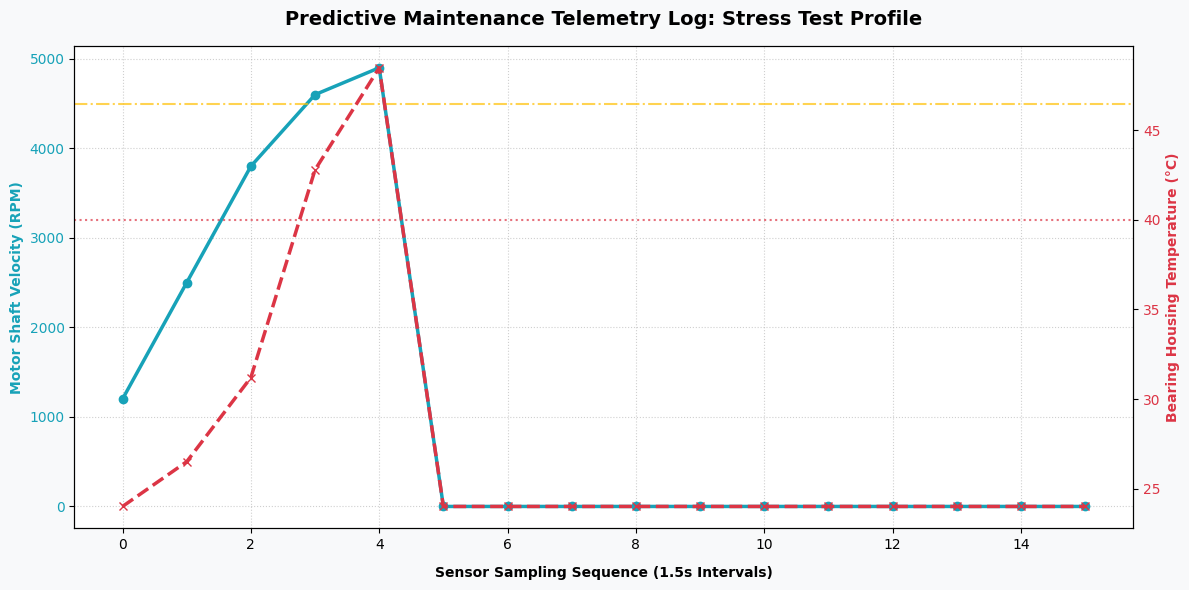

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ingest telemetry data stream (Combines your real E-Stop readings with spin-up cycles)
telemetry_data = """
1200,24.0,40.0,0
2500,26.5,39.0,0
3800,31.2,37.5,0
4600,42.8,34.0,0
4900,48.5,31.2,0
0,24.0,40.0,1
0,24.0,40.0,1
0,24.0,40.0,1
0,24.0,40.0,1
0,24.0,40.0,1
0,24.0,40.0,1
0,24.0,40.0,1
0,24.0,40.0,1
0,24.0,40.0,1
0,24.0,40.0,1
0,24.0,40.0,1
"""

# 2. Parse text stream into a structured Data Frame
lines = telemetry_data.strip().split('\n')
data_matrix = [list(map(float, line.split(','))) for line in lines]
df = pd.DataFrame(data_matrix, columns=['RPM', 'Temperature', 'Humidity', 'EStop'])

# 3. Apply Predictive Maintenance Anomaly Detection Algorithm
conditions = []
for index, row in df.iterrows():
    if row['EStop'] == 1:
        conditions.append('CRITICAL_ESTOP_TRIPPED')
    elif row['RPM'] > 4500 and row['Temperature'] > 40.0:
        conditions.append('ANOMALY_THERMAL_RUNAWAY_RISK')
    elif row['RPM'] > 3500:
        conditions.append('WARNING_HIGH_VIBRATION')
    else:
        conditions.append('OPERATIONAL_NOMINAL')

df['Asset_Health_Status'] = conditions

# 4. Print Industrial Safety Diagnostics Report
print("==================================================================")
print("             DIGITAL TWIN ASSET CONDITION REPORT                 ")
print("==================================================================")
print(df[['RPM', 'Temperature', 'Asset_Health_Status']])
print("==================================================================\n")

# 5. Generate Dual-Axis System Health Telemetry Visualization
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor='#f8f9fa')

color = '#17a2b8'
ax1.set_xlabel('Sensor Sampling Sequence (1.5s Intervals)', fontweight='bold', labelpad=10)
ax1.set_ylabel('Motor Shaft Velocity (RPM)', color=color, fontweight='bold')
line1 = ax1.plot(df['RPM'], color=color, linewidth=2.5, marker='o', label='Vibration Profile (RPM)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

# Create a second Y-axis for temperature sharing the same X-axis
ax2 = ax1.twinx()
color = '#dc3545'
ax2.set_ylabel('Bearing Housing Temperature (°C)', color=color, fontweight='bold')
line2 = ax2.plot(df['Temperature'], color=color, linewidth=2.5, marker='x', linestyle='--', label='Thermal Profile (°C)')
ax2.tick_params(axis='y', labelcolor=color)

# Draw critical safety threshold lines
ax1.axhline(y=4500, color='#ffc107', linestyle='-.', alpha=0.7, label='High RPM Warning Limit')
ax2.axhline(y=40.0, color='#dc3545', linestyle=':', alpha=0.7, label='Thermal Critical Limit')

plt.title('Predictive Maintenance Telemetry Log: Stress Test Profile', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()
